# How are in-demand skills trending for Data Analysts?

#### Methology
1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand


## Import Libraries and Data

In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Group the Skills by Month

Select only those job postings that are for Data Analysts and the job country is the EU region.

In [2]:
europe_countries = [
    "Albania", "Andorra", "Austria", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus",
    "Czech Republic", "Denmark", "Estonia", "Finland", "France",
    "Germany", "Greece", "Hungary", "Iceland", "Ireland",
    "Italy", "Kosovo", "Latvia", "Liechtenstein", "Lithuania",
    "Luxembourg", "Malta", "Moldova", "Monaco", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia", "Slovakia",
    "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine",
    "United Kingdom", "Vatican City"
]

df_eu = df[df['job_country'].isin(europe_countries)]
df_eu = df_eu[df_eu['job_title_short'] == 'Data Analyst']
# Create column with month number
df_eu['job_posted_month'] = df_eu['job_posted_date'].dt.month
# Explode job_skills column
df_eu_explode = df_eu.explode('job_skills')

Create a pivot table from the df_DA_US_explode, setting 'month' as the index, job_skills as the columns, and fills missing entries with zero.

In [21]:

df_eu_pivot = df_eu_explode.pivot_table(
    index = 'job_posted_month', 
    columns= 'job_skills', 
    aggfunc = 'size', 
    fill_value=0 )
df_eu_pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,arch,asana,asp.net,asp.net core,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,101,4,212,25,2,10,0,10,6,0,...,6,64,0,349,0,0,5,0,6,33
2,96,0,137,17,0,7,0,11,1,0,...,2,57,0,245,1,0,4,0,2,13
3,109,1,134,20,0,12,0,2,1,0,...,2,66,0,218,0,0,3,0,2,14
4,79,1,115,8,0,5,0,4,1,0,...,3,52,1,246,0,0,1,0,0,5
5,69,5,95,12,0,9,0,3,0,0,...,4,23,1,175,0,1,0,0,3,4
6,84,1,99,16,0,7,0,3,1,0,...,5,38,3,236,0,5,0,0,4,7
7,91,0,96,6,0,4,0,8,4,0,...,3,45,0,199,0,2,0,0,3,14
8,63,1,81,9,0,3,1,2,2,1,...,3,44,6,199,0,0,0,0,4,7
9,42,0,77,9,0,10,2,6,3,0,...,0,39,1,202,0,1,0,0,1,4


#### Sort columns by count and change month numbers to names

It adds a new row labeled `Total` that sums up counts across all months for each skill. Finally, it reorders the columns based on the total counts, displaying them from highest to lowest, and shows the updated pivot table. 

In [22]:
df_eu_pivot.loc['Total'] = df_eu_pivot.sum()
df_eu_pivot = df_eu_pivot[df_eu_pivot.loc['Total'].sort_values(ascending = False).index]
df_eu_pivot = df_eu_pivot.drop('Total')
df_eu_pivot

job_skills,sql,python,excel,power bi,tableau,r,sas,sap,azure,powerpoint,...,esquisse,f#,google chat,ovh,next.js,nuxt.js,mlr,mattermost,workfront,xamarin
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,3790,2380,2400,1830,1650,1168,1108,550,549,440,...,0,0,0,0,0,1,0,0,0,0
2,3004,1913,1881,1447,1374,941,878,463,451,309,...,0,0,0,0,0,0,0,0,1,0
3,2766,1850,1731,1347,1261,904,798,409,410,324,...,0,0,0,0,0,0,0,0,0,0
4,2570,1723,1613,1302,1109,788,764,412,388,295,...,0,1,0,1,0,0,0,0,0,0
5,2323,1539,1443,1137,972,667,566,361,364,242,...,0,0,0,0,0,0,0,0,0,0
6,2667,1736,1732,1363,1108,747,648,432,393,294,...,0,0,0,0,0,0,0,0,0,0
7,2650,1757,1738,1418,1140,798,586,438,443,295,...,0,0,0,0,0,0,0,0,0,0
8,2523,1674,1648,1345,1102,787,624,483,438,224,...,0,0,0,0,0,0,0,0,0,0
9,2331,1534,1495,1246,950,692,486,387,390,217,...,0,0,0,0,0,0,0,0,0,0


## Plot the Monthly Skill Counts

Plot a line chart of the top 5 skills for data analysts, indexed by month. It selects the first five columns and plots them. 

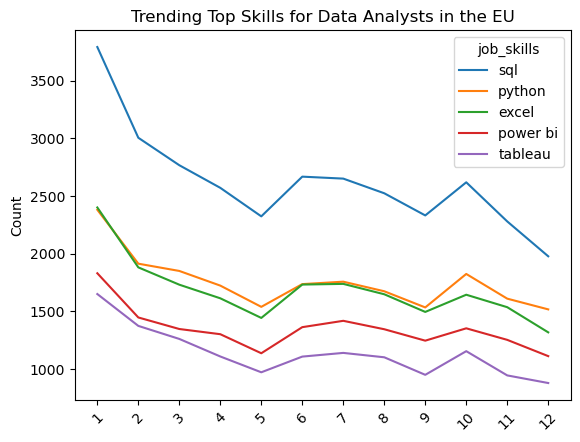

In [23]:
df_eu_pivot.iloc[:, :5].plot(kind='line')

plt.title('Trending Top Skills for Data Analysts in the EU')
plt.ylabel('Count')
plt.xlabel('')
plt.xticks(
    ticks= range(len(df_eu_pivot.index)), 
    labels = df_eu_pivot.index, 
    rotation = 45)
plt.show()

This is good but totals can be misleading without context. Percentages clarify relationships within the whole, giving a more accurate comparison.
## Calculate Percentage of Total Jobs

In [ ]:
DA_total = df_eu.groupby('job_posted_month').size()
df_eu_perc = df_eu_pivot.div(DA_total/100,axis = 0).round(2)
#Converting number to mounth
df_eu_perc.index = (pd.to_datetime(df_eu_perc.index, format='%m').strftime('%b'))
df_eu_perc

job_skills,sql,python,excel,power bi,tableau,r,sas,sap,azure,powerpoint,...,esquisse,f#,google chat,ovh,next.js,nuxt.js,mlr,mattermost,workfront,xamarin
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,44.60,28.01,28.24,21.53,19.42,13.74,13.04,6.47,6.46,5.18,...,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00
Feb,45.79,29.16,28.67,22.05,20.94,14.34,13.38,7.06,6.87,4.71,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00
Mar,45.17,30.21,28.27,22.00,20.59,14.76,13.03,6.68,6.70,5.29,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Apr,45.97,30.82,28.85,23.29,19.84,14.09,13.66,7.37,6.94,5.28,...,0.00,0.02,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00
May,46.73,30.96,29.03,22.87,19.55,13.42,11.39,7.26,7.32,4.87,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Jun,44.78,29.15,29.08,22.88,18.60,12.54,10.88,7.25,6.60,4.94,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Jul,45.15,29.94,29.61,24.16,19.42,13.60,9.98,7.46,7.55,5.03,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Aug,42.67,28.31,27.87,22.75,18.64,13.31,10.55,8.17,7.41,3.79,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Sep,42.75,28.14,27.42,22.85,17.42,12.69,8.91,7.10,7.15,3.98,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## Plot Monthly Skill Demand 

Creates a line plot for the top five skills of data analysts, shown as percentages of the total job entries per month, using the first 5 columns of the `df_DA_pivot_percent` DataFrame. Also the legend is moved outside of the plot for readability.

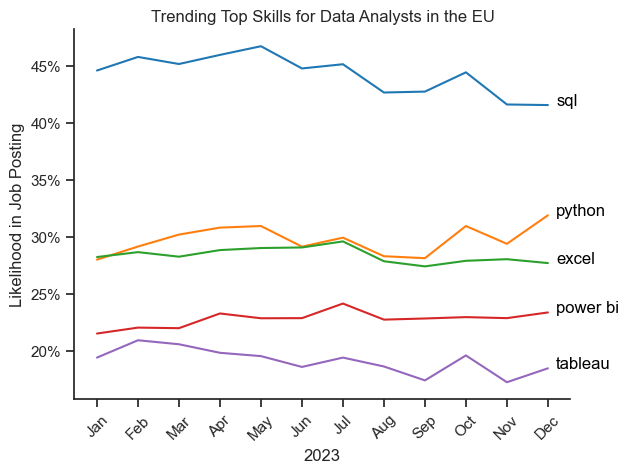

In [ ]:
df_plot = df_eu_perc.iloc[:, :5]

sns.lineplot(
    data=df_plot, 
    dashes=False, 
    legend='full', 
    palette='tab10')
sns.set_theme(style='ticks')
plt.legend().remove()
sns.despine() 



plt.title('Trending Top Skills for Data Analysts in the EU')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.xticks(
    ticks= range(len(df_eu_perc.index)), 
    labels = df_eu_perc.index, 
    rotation = 45)

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}%'))
plt.show()